# <font color="red">Variable Cholesterol</font>


Cette fois, on ne traite plus la variable binaire `Heart_Disease_Risk`, mais la variable quantitative **`Cholesterol_LDL`**. On est donc dans un **problème de régression**.

L'objectif est de reprendre la même logique d'étude que pour la classification :
- arbre CART de régression ;
- étude de la complexité et élagage ;
- bagging ;
- random forest ;
- boosting ;
- puis comparaison avec des modèles linéaires, un SVR et un réseau de neurones.

L'analyse exploratoire détaillée n'est **pas répétée** ici. On part directement de l'étude de modélisation, en gardant à l'esprit les tendances déjà observées sur ce jeu de données, en particulier le rôle très important de `Cholesterol_Total`, puis de variables comme `Age`, `BMI`, `Systolic_BP` ou `Cholesterol_HDL`.

## 1. Cadre de l'étude

Dans ce second objectif du projet, on cherche à prédire `Cholesterol_LDL` à partir de toutes les autres variables **à l'exception de `Heart_Disease_Risk`**.

Comme `Cholesterol_LDL` est une variable quantitative, les modèles seront évalués avec des métriques de régression, principalement :
- la **RMSE** (racine de l'erreur quadratique moyenne), facile à interpréter dans l'unité du LDL ;
- la **MAE**, plus robuste aux grosses erreurs ;
- le **$R^2$**, qui mesure la part de variance expliquée.

On conserve le fil directeur:
- les arbres sont non paramétriques, flexibles, mais à forte variance ;
- les méthodes d'agrégation cherchent à stabiliser ou améliorer ces arbres ;
- les modèles linéaires et régularisés servent de points de comparaison importants ;
- le SVR et le réseau de neurones apportent d'autres formes de non-linéarité.

Pour les modèles coûteux (`SVR`, `MLPRegressor`), on adopte une stratégie raisonnable pour un notebook exécutable : une **validation croisée sur un sous-échantillon d'apprentissage**, puis un réentraînement final sur l'échantillon complet d'apprentissage avec les hyperparamètres retenus.

In [14]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

In [15]:
project_dir = Path.cwd()
if not (project_dir / 'divers').exists():
    project_dir = project_dir.parent

data_path = project_dir / 'divers' / 'healthcare_synthetic_data.csv'
healthcare = pd.read_csv(data_path)

X = healthcare.drop(columns=['Patient_ID', 'Cholesterol_LDL', 'Heart_Disease_Risk'])
X = pd.get_dummies(
    X,
    columns=['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History'],
    drop_first=True,
)
y = healthcare['Cholesterol_LDL']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

print('Dimensions apprentissage :', X_train.shape)
print('Dimensions test :', X_test.shape)
print('Moyenne LDL train/test :', round(y_train.mean(), 2), '/', round(y_test.mean(), 2))

Dimensions apprentissage : (11250, 19)
Dimensions test : (3750, 19)
Moyenne LDL train/test : 140.49 / 139.96


In [16]:
results = {}


def regression_scores(model, Xtr, Xte, ytr=y_train, yte=y_test):
    pred_train = model.predict(Xtr)
    pred_test = model.predict(Xte)
    return {
        'RMSE train': mean_squared_error(ytr, pred_train) ** 0.5,
        'RMSE test': mean_squared_error(yte, pred_test) ** 0.5,
        'MAE test': mean_absolute_error(yte, pred_test),
        'R2 train': r2_score(ytr, pred_train),
        'R2 test': r2_score(yte, pred_test),
    }


def store_result(name, model, fit_time, Xtr, Xte, ytr=y_train, yte=y_test, advantages='', limits='', category=''):
    scores = regression_scores(model, Xtr, Xte, ytr=ytr, yte=yte)
    results[name] = {
        'Modèle': name,
        'Famille': category,
        'RMSE train': round(scores['RMSE train'], 3),
        'RMSE test': round(scores['RMSE test'], 3),
        'MAE test': round(scores['MAE test'], 3),
        'R2 train': round(scores['R2 train'], 4),
        'R2 test': round(scores['R2 test'], 4),
        'Temps entraînement (s)': round(fit_time, 3),
    }


def top_coefficients(coefs, columns, top_n=10):
    serie = pd.Series(coefs, index=columns)
    return serie.reindex(serie.abs().sort_values(ascending=False).index).head(top_n)


scaler_full = StandardScaler().fit(X_train)
X_train_scaled = scaler_full.transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

## 2. Modèles linéaires 

Avant d'étudier les arbres et les méthodes d'ensemble, il est utile de construire plusieurs références linéaires.

On compare ici :
- une **régression linéaire complète** ;
- une régression linéaire **après sélection de variables** ;
- une régression **ridge** ;
- une régression **lasso**.



In [17]:
start = time.perf_counter()
linear_full = LinearRegression()
linear_full.fit(X_train, y_train)
linear_full_time = time.perf_counter() - start

store_result(
    'Régression linéaire complète',
    linear_full,
    linear_full_time,
    X_train,
    X_test,

    category='Linéaire',
)

linear_full_scores = regression_scores(linear_full, X_train, X_test)
print(linear_full_scores)
print(top_coefficients(linear_full.coef_, X_train.columns))

{'RMSE train': 10.049633391911389, 'RMSE test': 9.835666602848148, 'MAE test': 7.798787190641316, 'R2 train': 0.6867616622569079, 'R2 test': 0.6939523470147986}
Cholesterol_Total            0.652554
Family_History_1            -0.370429
Physical_Activity_Level_2   -0.213832
Physical_Activity_Level_1   -0.202981
Alcohol_Consumption_2        0.109943
BMI                         -0.081525
Alcohol_Consumption_1        0.079334
Gender_1                    -0.077039
Smoking_Status_1             0.071252
Physical_Activity_Level_3    0.055889
dtype: float64


In [18]:
start = time.perf_counter()
lasso_selector = LassoCV(alphas=np.logspace(-3, 1, 20), cv=5, random_state=42, max_iter=10000)
lasso_selector.fit(X_train_scaled, y_train)
selector = SelectFromModel(lasso_selector, prefit=True)
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)
selected_columns = X_train.columns[selector.get_support()].tolist()

linear_selected = LinearRegression()
linear_selected.fit(X_train_selected, y_train)
linear_selected_time = time.perf_counter() - start

store_result(
    'Régression linéaire sélectionnée',
    linear_selected,
    linear_selected_time,
    X_train_selected,
    X_test_selected,
    category='Linéaire',
)

print('Variables retenues :', selected_columns)
print(regression_scores(linear_selected, X_train_selected, X_test_selected))

Variables retenues : ['Age', 'Systolic_BP', 'Cholesterol_Total', 'Family_History_1']
{'RMSE train': 10.052204236182959, 'RMSE test': 9.832157138850766, 'MAE test': 7.7942999870631455, 'R2 train': 0.6866013797954585, 'R2 test': 0.6941707097643222}


In [19]:
start = time.perf_counter()
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)
ridge_model.fit(X_train_scaled, y_train)
ridge_time = time.perf_counter() - start

store_result(
    'Ridge',
    ridge_model,
    ridge_time,
    X_train_scaled,
    X_test_scaled,
    category='Linéaire pénalisé',
)

start = time.perf_counter()
lasso_model = LassoCV(alphas=np.logspace(-3, 1, 20), cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_time = time.perf_counter() - start

store_result(
    'Lasso',
    lasso_model,
    lasso_time,
    X_train_scaled,
    X_test_scaled,
    advantages="Pénalise et sélectionne automatiquement les variables.",
    limits="Peut être instable si plusieurs variables portent une information proche.",
    category='Linéaire pénalisé',
)

print('Alpha ridge :', ridge_model.alpha_)
print('Alpha lasso :', lasso_model.alpha_)
print('Nombre de coefficients non nuls du lasso :', int((np.abs(lasso_model.coef_) > 1e-8).sum()))

Alpha ridge : 31.622776601683793
Alpha lasso : 0.12742749857031335
Nombre de coefficients non nuls du lasso : 4


On s'attend à ce que les modèles linéaires soient déjà performants, car l'analyse exploratoire précédente montrait une très forte liaison entre `Cholesterol_Total` et `Cholesterol_LDL`. 

## 3. CART de régression

On reprend maintenant l'étude dans l'esprit CART précédent, mais en régression. Cette fois, l'hétérogénéité dans les noeuds est mesurée à partir de la **variance intra-noeud**. L'arbre cherche donc des coupures qui réduisent la dispersion de `Cholesterol_LDL` dans les feuilles.

Comme en classification, l'arbre de régression est très lisible, mais il peut devenir instable et sur-ajuster si on laisse la complexité croître sans contrôle.

In [20]:
tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        'max_depth': list(range(2, 11)),
        'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

t0 = time.perf_counter()
tree_search.fit(X_train, y_train)
cart_reg = tree_search.best_estimator_
cart_time = time.perf_counter() - t0

store_result(
    'CART régression',
    cart_reg,
    cart_time,
    X_train,
    X_test,
    category='Arbre',
)

print('Meilleurs paramètres :', tree_search.best_params_)
print('Meilleur score CV (RMSE) :', round(-tree_search.best_score_, 3))
print('Profondeur retenue :', cart_reg.get_depth())
print('Nombre de feuilles :', cart_reg.get_n_leaves())

Meilleurs paramètres : {'max_depth': 5, 'min_samples_leaf': 10}
Meilleur score CV (RMSE) : 10.183
Profondeur retenue : 5
Nombre de feuilles : 32


Cholesterol_Total      0.996222
Age                    0.002090
Height_cm              0.000784
Diastolic_BP           0.000521
Weight_kg              0.000384
Systolic_BP            0.000000
BMI                    0.000000
Cholesterol_HDL        0.000000
Fasting_Blood_Sugar    0.000000
Stress_Level           0.000000
dtype: float64


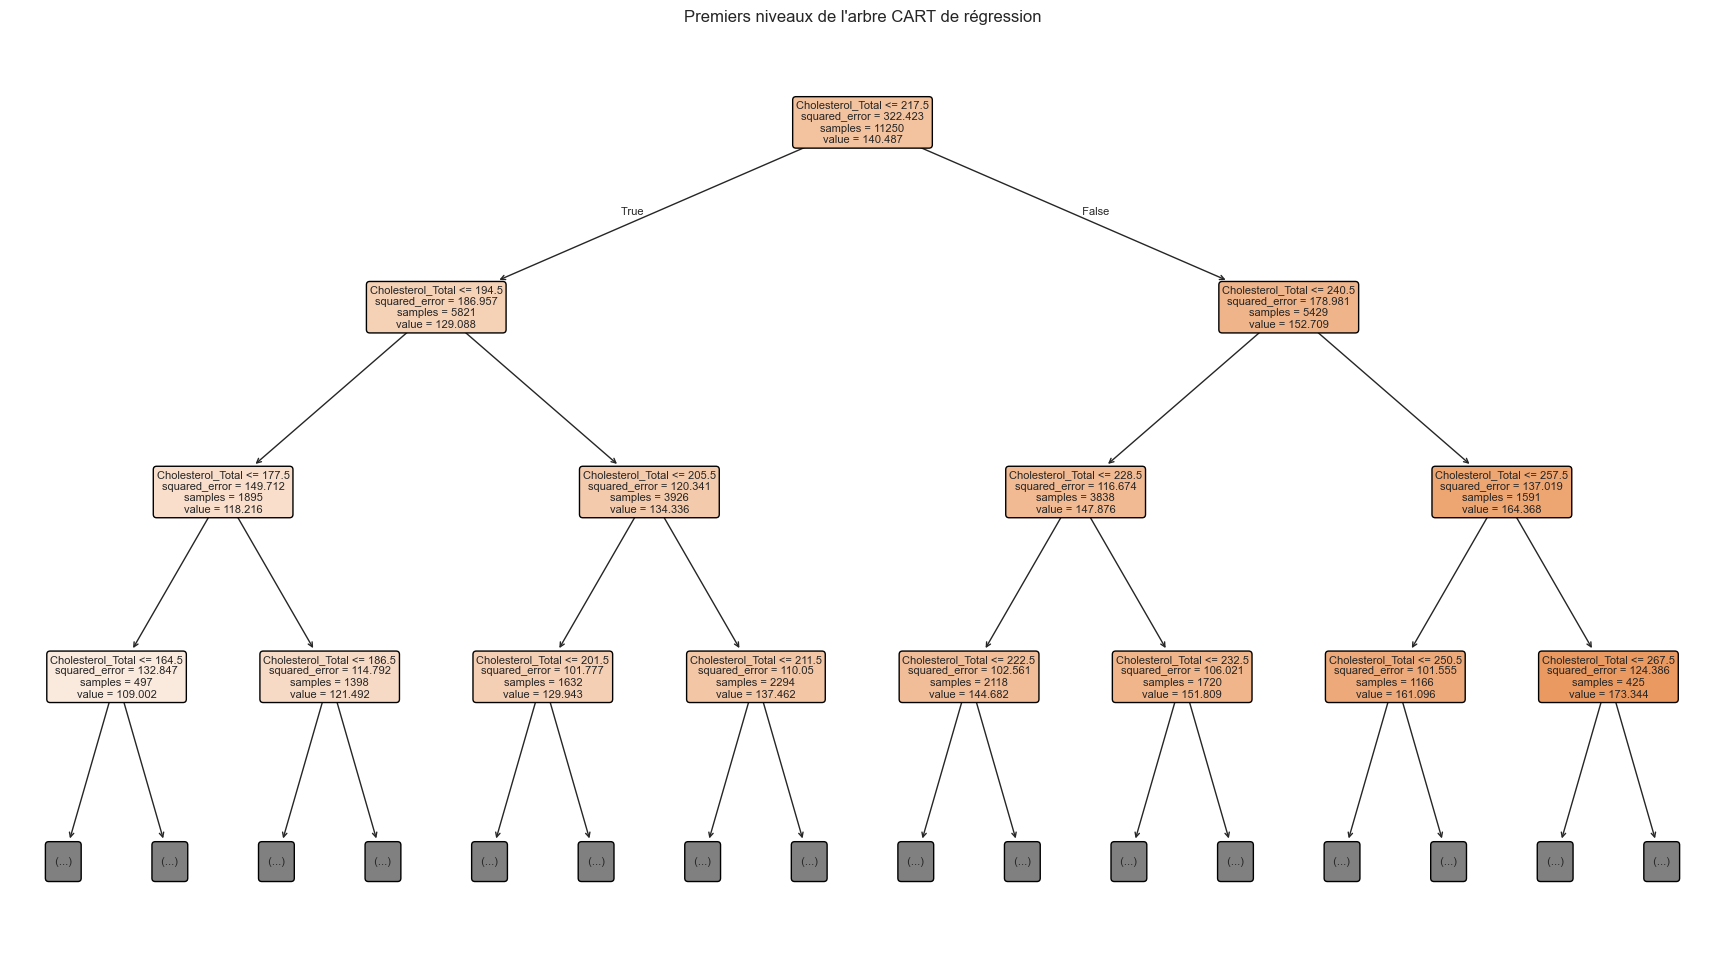

In [21]:
cart_importances = pd.Series(cart_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(cart_importances.head(10))

plt.figure(figsize=(22, 12))
plot_tree(
    cart_reg,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title('Premiers niveaux de l\'arbre CART de régression')
plt.show()

On voit bien ici que le cholesterol total explique à lui tout seul le Cholesterol LDL (logique).

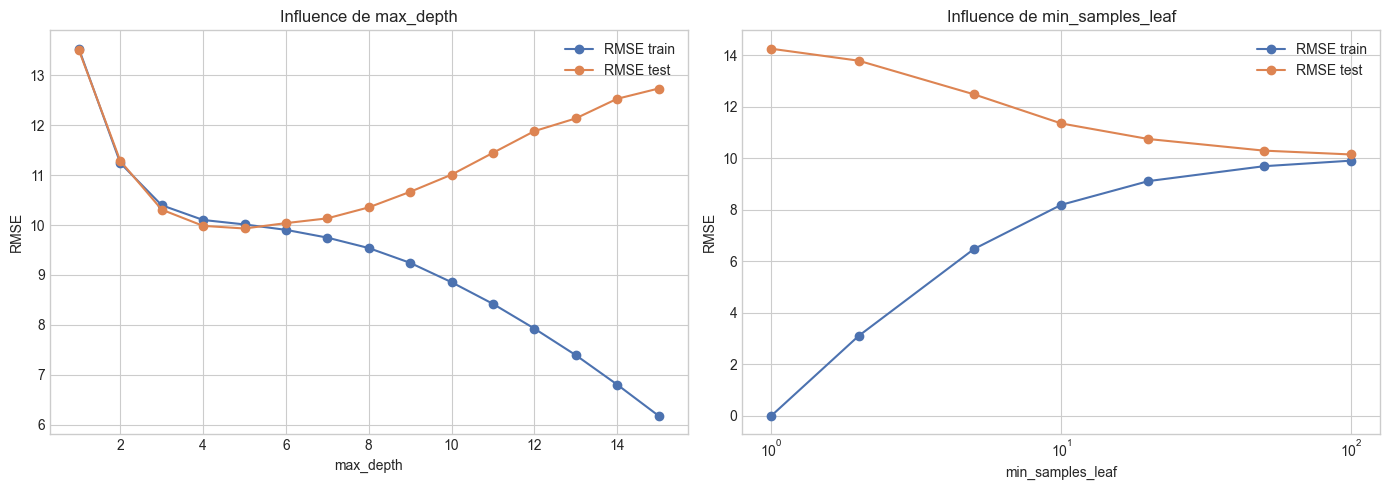

In [22]:
depth_values = list(range(1, 16))
leaf_values = [1, 2, 5, 10, 20, 50, 100]

depth_rows = []
for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    scores = regression_scores(model, X_train, X_test)
    depth_rows.append({
        'max_depth': depth,
        'RMSE train': scores['RMSE train'],
        'RMSE test': scores['RMSE test'],
        'nb_feuilles': model.get_n_leaves(),
    })

depth_df = pd.DataFrame(depth_rows)

leaf_rows = []
for leaf in leaf_values:
    model = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    scores = regression_scores(model, X_train, X_test)
    leaf_rows.append({
        'min_samples_leaf': leaf,
        'RMSE train': scores['RMSE train'],
        'RMSE test': scores['RMSE test'],
        'nb_feuilles': model.get_n_leaves(),
    })

leaf_df = pd.DataFrame(leaf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(depth_df['max_depth'], depth_df['RMSE train'], marker='o', label='RMSE train')
axes[0].plot(depth_df['max_depth'], depth_df['RMSE test'], marker='o', label='RMSE test')
axes[0].set_title('Influence de max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(leaf_df['min_samples_leaf'], leaf_df['RMSE train'], marker='o', label='RMSE train')
axes[1].plot(leaf_df['min_samples_leaf'], leaf_df['RMSE test'], marker='o', label='RMSE test')
axes[1].set_title('Influence de min_samples_leaf')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_xscale('log')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()


- un arbre trop profond apprend très bien l'échantillon d'apprentissage, mais sa performance de test ne suit pas nécessairement ;
- un arbre trop peu profond devient trop rigide ;
- l'écart train/test mesure bien la forte variance des arbres.

## 4. Élagage et sélection de complexité

On introduit ensuite une pénalisation de la complexité via le **cost-complexity pruning**. En régression aussi, l'idée est de partir d'un arbre potentiellement trop grand puis de supprimer certaines branches si leur gain ne justifie plus leur complexité.

In [23]:
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
alpha_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 0.95, 15)))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
pruning_rows = []
for alpha in alpha_grid:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=float(alpha))
    cv_score = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    model.fit(X_train, y_train)
    scores = regression_scores(model, X_train, X_test)
    pruning_rows.append({
        'ccp_alpha': float(alpha),
        'RMSE train': scores['RMSE train'],
        'RMSE test': scores['RMSE test'],
        'RMSE CV': cv_score,
        'nb_feuilles': model.get_n_leaves(),
    })

pruning_df = pd.DataFrame(pruning_rows)
best_alpha = pruning_df.loc[pruning_df['RMSE CV'].idxmin(), 'ccp_alpha']

start = time.perf_counter()
pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=float(best_alpha))
pruned_tree.fit(X_train, y_train)
pruned_time = time.perf_counter() - start

store_result(
    'CART élagué',
    pruned_tree,
    pruned_time,
    X_train,
    X_test,
    category='Arbre',
)

print('Meilleur alpha :', best_alpha)
print('Nombre de feuilles après élagage :', pruned_tree.get_n_leaves())
print(regression_scores(pruned_tree, X_train, X_test))

Meilleur alpha : 0.03595505665266855
Nombre de feuilles après élagage : 942
{'RMSE train': 7.291904402870775, 'RMSE test': 12.1179127998797, 'MAE test': 9.55187775475017, 'R2 train': 0.8350864254448529, 'R2 test': 0.5354450403179937}


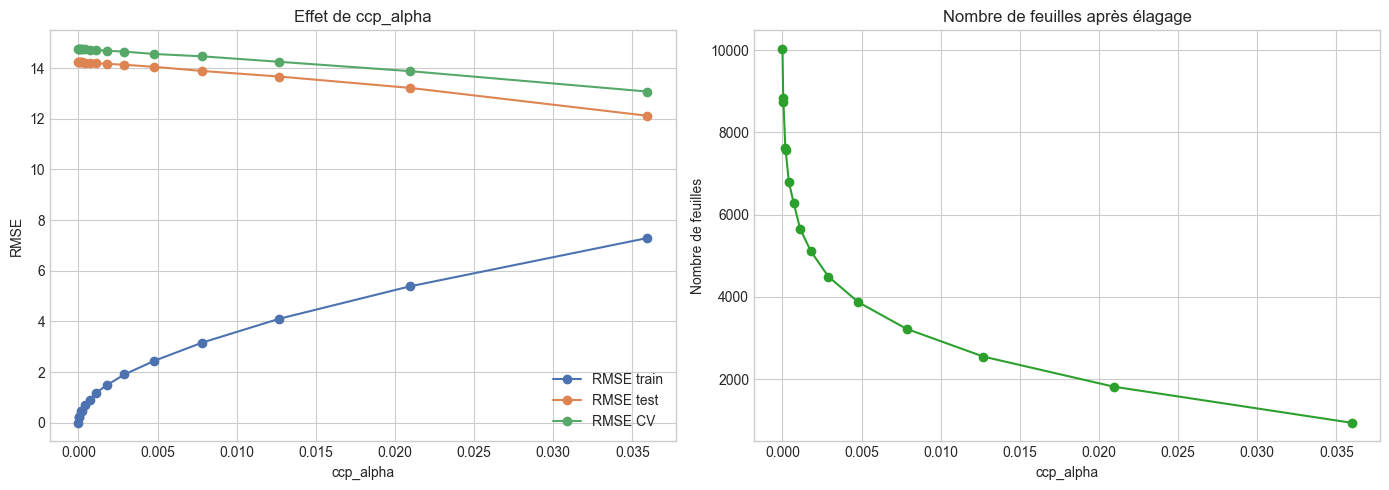

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(pruning_df['ccp_alpha'], pruning_df['RMSE train'], marker='o', label='RMSE train')
axes[0].plot(pruning_df['ccp_alpha'], pruning_df['RMSE test'], marker='o', label='RMSE test')
axes[0].plot(pruning_df['ccp_alpha'], pruning_df['RMSE CV'], marker='o', label='RMSE CV')
axes[0].set_title('Effet de ccp_alpha')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(pruning_df['ccp_alpha'], pruning_df['nb_feuilles'], marker='o', color='tab:green')
axes[1].set_title('Nombre de feuilles après élagage')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Nombre de feuilles')

plt.tight_layout()
plt.show()

## 5. Bagging

Le bagging est directement pertinent pour les arbres de régression, qui sont instables. Le principe est identique au cas classification : on apprend plusieurs arbres sur des échantillons bootstrap, puis on **moyenne** leurs prédictions. Le but principal est la **réduction de variance**.

In [25]:
bag_search = GridSearchCV(
    BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    {
        'estimator__min_samples_leaf': [1, 5, 10, 20],
        'n_estimators': [100, 200],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
bag_search.fit(X_train, y_train)
bag_model = bag_search.best_estimator_
bag_time = time.perf_counter() - start

store_result(
    'Bagging',
    bag_model,
    bag_time,
    X_train,
    X_test,
    category='Agrégation',
)

print('Meilleurs paramètres bagging :', bag_search.best_params_)
print('RMSE CV :', round(-bag_search.best_score_, 3))
print('Score OOB (R2) :', round(bag_model.oob_score_, 4))
print(regression_scores(bag_model, X_train, X_test))

Meilleurs paramètres bagging : {'estimator__min_samples_leaf': 20, 'n_estimators': 200}
RMSE CV : 10.189
Score OOB (R2) : 0.678
{'RMSE train': 9.012002807663096, 'RMSE test': 9.94380657982863, 'MAE test': 7.897950968910273, 'R2 train': 0.7481064139869603, 'R2 test': 0.6871855609227822}


## 6. Random Forest

La random forest ajoute au bagging une randomisation sur les variables candidates à chaque noeud. Dans le cas régression, cette stratégie reste motivée par la recherche d'une réduction de corrélation entre arbres, donc d'une baisse de variance de l'estimateur.

In [26]:
rf_search = GridSearchCV(
    RandomForestRegressor(
        n_estimators=200,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    {
        'max_depth': [8, 10, None],
        'max_features': [5, 'sqrt', None],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
rf_time = time.perf_counter() - start

store_result(
    'Random Forest',
    rf_model,
    rf_time,
    X_train,
    X_test,
    category='Agrégation',
)

print('Meilleurs paramètres RF :', rf_search.best_params_)
print('RMSE CV :', round(-rf_search.best_score_, 3))
print('Score OOB (R2) :', round(rf_model.oob_score_, 4))
print(regression_scores(rf_model, X_train, X_test))

Meilleurs paramètres RF : {'max_depth': 8, 'max_features': None}
RMSE CV : 10.166
Score OOB (R2) : 0.68
{'RMSE train': 9.233190036900861, 'RMSE test': 9.909164459046162, 'MAE test': 7.868112451022758, 'R2 train': 0.7355899118211136, 'R2 test': 0.6893613231642026}


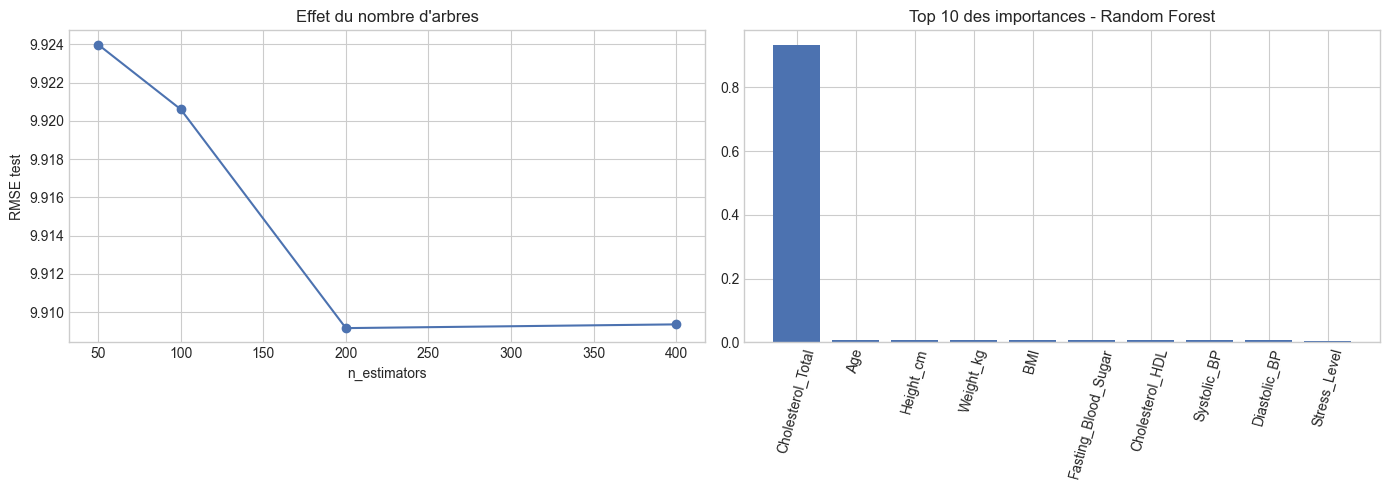

Cholesterol_Total      0.932180
Age                    0.008332
Height_cm              0.007887
Weight_kg              0.007454
BMI                    0.007420
Fasting_Blood_Sugar    0.007287
Cholesterol_HDL        0.006522
Systolic_BP            0.006463
Diastolic_BP           0.005782
Stress_Level           0.003684
dtype: float64


In [27]:
rf_curve_rows = []
for n_trees in [50, 100, 200, 400]:
    rf_tmp = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=rf_search.best_params_['max_depth'],
        max_features=rf_search.best_params_['max_features'],
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    rf_tmp.fit(X_train, y_train)
    scores = regression_scores(rf_tmp, X_train, X_test)
    rf_curve_rows.append({
        'n_estimators': n_trees,
        'RMSE test': scores['RMSE test'],
        'R2 OOB': rf_tmp.oob_score_,
    })

rf_curve_df = pd.DataFrame(rf_curve_rows)
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rf_curve_df['n_estimators'], rf_curve_df['RMSE test'], marker='o', label='RMSE test')
axes[0].set_title("Effet du nombre d'arbres")
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('RMSE test')

axes[1].bar(rf_importances.head(10).index, rf_importances.head(10).values)
axes[1].set_title('Top 10 des importances - Random Forest')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

print(rf_importances.head(10))

Encore une fois la variable Cholesterol_Total sur-domine l'analyse. 
Le nombre d'arbre optimal lui se situe autour de 200 pour la forêt.

## 7. Boosting

En régression aussi, le boosting construit un modèle additif séquentiel. Chaque nouvel arbre cherche à corriger ce que le modèle précédent n'expliquait pas correctement.

On compare ici deux versions simples et cohérentes avec le cours :
- **AdaBoostRegressor** ;
- **GradientBoostingRegressor**.

Le but est de voir si la construction séquentielle apporte un gain par rapport aux arbres seuls ou agrégés par bagging. (résultats à la fin de l'étude)

In [28]:
ada_search = GridSearchCV(
    AdaBoostRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42,
    ),
    {
        'estimator__max_depth': [2, 3],
        'n_estimators': [100, 200],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
ada_search.fit(X_train, y_train)
ada_model = ada_search.best_estimator_
ada_time = time.perf_counter() - start

store_result(
    'AdaBoost',
    ada_model,
    ada_time,
    X_train,
    X_test,
    category='Boosting',
)

print('Meilleurs paramètres AdaBoost :', ada_search.best_params_)
print('RMSE CV :', round(-ada_search.best_score_, 3))
print(regression_scores(ada_model, X_train, X_test))

Meilleurs paramètres AdaBoost : {'estimator__max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200}
RMSE CV : 10.162
{'RMSE train': 10.09528636676199, 'RMSE test': 9.96666999029717, 'MAE test': 7.901934017897891, 'R2 train': 0.6839092709992872, 'R2 test': 0.6857454228774592}


In [29]:
gbr_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators': [200, 300],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [1, 2],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
gbr_search.fit(X_train, y_train)
gbr_model = gbr_search.best_estimator_
gbr_time = time.perf_counter() - start

store_result(
    'Gradient Boosting',
    gbr_model,
    gbr_time,
    X_train,
    X_test,
    category='Boosting',
)

print('Meilleurs paramètres Gradient Boosting :', gbr_search.best_params_)
print('RMSE CV :', round(-gbr_search.best_score_, 3))
print(regression_scores(gbr_model, X_train, X_test))

Meilleurs paramètres Gradient Boosting : {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 300}
RMSE CV : 10.097
{'RMSE train': 10.00996795548022, 'RMSE test': 9.871649712134356, 'MAE test': 7.832830182567315, 'R2 train': 0.6892294568446571, 'R2 test': 0.6917089422897948}


Cholesterol_Total      0.998451
Age                    0.000549
Cholesterol_HDL        0.000341
Weight_kg              0.000268
Systolic_BP            0.000164
Diastolic_BP           0.000091
Height_cm              0.000077
BMI                    0.000059
Fasting_Blood_Sugar    0.000000
Stress_Level           0.000000
dtype: float64


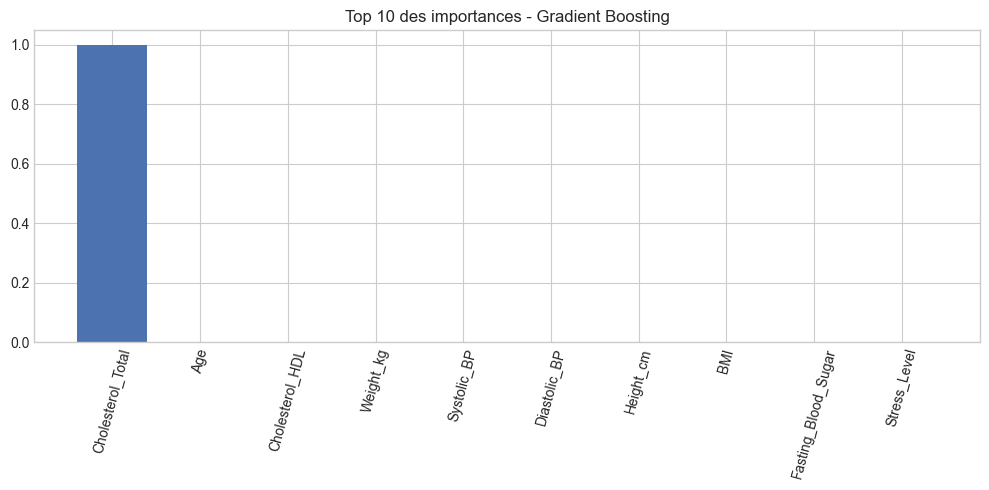

In [30]:
gbr_importances = pd.Series(gbr_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(gbr_importances.head(10))

plt.figure(figsize=(10, 5))
plt.bar(gbr_importances.head(10).index, gbr_importances.head(10).values)
plt.title('Top 10 des importances - Gradient Boosting')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 8. SVR

Le **Support Vector Regression** reprend les idées des SVM dans un cadre de régression. On cherche une fonction aussi régulière que possible, tout en tolérant des écarts inférieurs à `epsilon`.

Les hyperparamètres principaux sont :
- `C`, qui règle la pénalisation des écarts ;
- `epsilon`, qui fixe la largeur du tube d'insensibilité ;
- `kernel` et éventuellement `gamma`, qui contrôlent la forme de la non-linéarité.

La validation croisée complète sur tout l'échantillon serait coûteuse. On retient donc une stratégie raisonnable : CV sur un sous-échantillon d'apprentissage, puis réentraînement final sur l'échantillon complet.

In [31]:
X_train_svr_sub, _, y_train_svr_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=4000,
    random_state=42,
)

scaler_svr = StandardScaler().fit(X_train_svr_sub)
X_train_svr_sub_scaled = scaler_svr.transform(X_train_svr_sub)
X_test_svr_scaled = scaler_svr.transform(X_test)

svr_search = GridSearchCV(
    SVR(),
    {
        'kernel': ['linear', 'rbf'],
        'C': [0.5, 1, 5],
        'epsilon': [1, 2],
        'gamma': ['scale', 0.1],
    },
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
svr_search.fit(X_train_svr_sub_scaled, y_train_svr_sub)
svr_best_params = svr_search.best_params_
svr_time_search = time.perf_counter() - start

scaler_svr_full = StandardScaler().fit(X_train)
X_train_svr_scaled = scaler_svr_full.transform(X_train)
X_test_svr_scaled = scaler_svr_full.transform(X_test)

start = time.perf_counter()
svr_model = SVR(**svr_best_params)
svr_model.fit(X_train_svr_scaled, y_train)
svr_time_fit = time.perf_counter() - start

store_result(
    'SVR',
    svr_model,
    svr_time_search + svr_time_fit,
    X_train_svr_scaled,
    X_test_svr_scaled,
    category='SVR',
)

print('Meilleurs paramètres SVR :', svr_best_params)
print('RMSE CV (sous-échantillon) :', round(-svr_search.best_score_, 3))
print(regression_scores(svr_model, X_train_svr_scaled, X_test_svr_scaled))

Meilleurs paramètres SVR : {'C': 1, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}
RMSE CV (sous-échantillon) : 10.155
{'RMSE train': 10.054266051467511, 'RMSE test': 9.846494663979565, 'MAE test': 7.808563908057571, 'R2 train': 0.6864728037501795, 'R2 test': 0.6932781218782235}


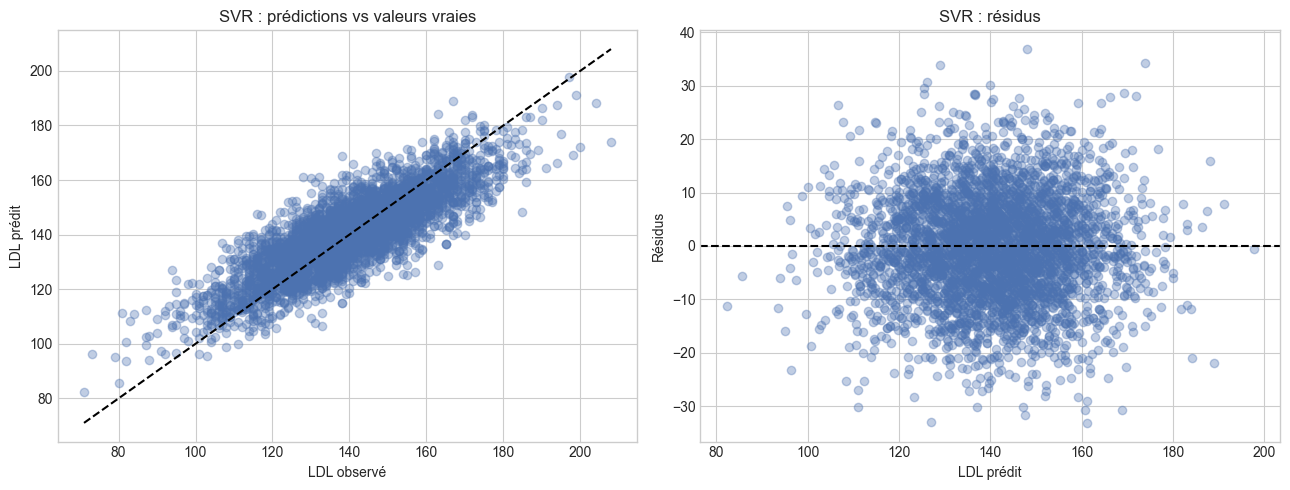

In [32]:
svr_pred = svr_model.predict(X_test_svr_scaled)
svr_resid = y_test - svr_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, svr_pred, alpha=0.35)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
axes[0].set_title('SVR : prédictions vs valeurs vraies')
axes[0].set_xlabel('LDL observé')
axes[0].set_ylabel('LDL prédit')

axes[1].scatter(svr_pred, svr_resid, alpha=0.35)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('SVR : résidus')
axes[1].set_xlabel('LDL prédit')
axes[1].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

## 9. Réseau de neurones

On réalise maintenant une études avec des réseaux de neurones. On retient ici un **MLPRegressor** très simple.

L'objectif n'est pas de faire du deep learning, mais de disposer d'un autre modèle non linéaire de référence.

In [33]:
X_train_mlp_sub, _, y_train_mlp_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=4000,
    random_state=42,
)

scaler_mlp = StandardScaler().fit(X_train_mlp_sub)
X_train_mlp_sub_scaled = scaler_mlp.transform(X_train_mlp_sub)
X_test_mlp_scaled = scaler_mlp.transform(X_test)

mlp_search = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=42),
    {
        'hidden_layer_sizes': [(20,), (40,), (40, 20)],
        'alpha': [1e-4, 1e-3, 1e-2],
    },
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
mlp_search.fit(X_train_mlp_sub_scaled, y_train_mlp_sub)
mlp_best_params = mlp_search.best_params_
mlp_time_search = time.perf_counter() - start

scaler_mlp_full = StandardScaler().fit(X_train)
X_train_mlp_scaled = scaler_mlp_full.transform(X_train)
X_test_mlp_scaled = scaler_mlp_full.transform(X_test)

start = time.perf_counter()
mlp_model = MLPRegressor(max_iter=500, random_state=42, **mlp_best_params)
mlp_model.fit(X_train_mlp_scaled, y_train)
mlp_time_fit = time.perf_counter() - start

store_result(
    'Réseau de neurones (MLP)',
    mlp_model,
    mlp_time_search + mlp_time_fit,
    X_train_mlp_scaled,
    X_test_mlp_scaled,
    category='Réseau de neurones',
)

print('Meilleurs paramètres MLP :', mlp_best_params)
print('RMSE CV (sous-échantillon) :', round(-mlp_search.best_score_, 3))
print(regression_scores(mlp_model, X_train_mlp_scaled, X_test_mlp_scaled))

c:\Users\deler\anaconda3\envs\ML\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Meilleurs paramètres MLP : {'alpha': 0.01, 'hidden_layer_sizes': (40, 20)}
RMSE CV (sous-échantillon) : 11.095
{'RMSE train': 9.79925002136519, 'RMSE test': 10.168258358962554, 'MAE test': 8.06617735558152, 'R2 train': 0.7021756863925298, 'R2 test': 0.672904477046406}


## 10. Comparaison globale des modèles

On rassemble maintenant l'ensemble des modèles optimisés sur l'échantillon de test. La comparaison porte à la fois sur la précision, la stabilité implicite via l'écart train/test, le coût d'entraînement et l'interprétabilité.

In [37]:
comparison_df = pd.DataFrame(results).T.sort_values('RMSE test')
comparison_df

,Modèle,Famille,RMSE train,RMSE test,MAE test,R2 train,R2 test,Temps entraînement (s)
Lasso,Lasso,Linéaire pénalisé,10.054,9.828,7.789,0.6865,0.6944,0.109
Régression linéaire sélectionnée,Régression linéaire sélectionnée,Linéaire,10.052,9.832,7.794,0.6866,0.6942,0.116
Régression linéaire complète,Régression linéaire complète,Linéaire,10.05,9.836,7.799,0.6868,0.694,0.012
Ridge,Ridge,Linéaire pénalisé,10.05,9.836,7.8,0.6868,0.6939,0.416
SVR,SVR,SVR,10.054,9.846,7.809,0.6865,0.6933,12.058
Gradient Boosting,Gradient Boosting,Boosting,10.01,9.872,7.833,0.6892,0.6917,21.484
Random Forest,Random Forest,Agrégation,9.233,9.909,7.868,0.7356,0.6894,38.017
CART régression,CART régression,Arbre,10.012,9.926,7.86,0.6891,0.6883,9.936
Bagging,Bagging,Agrégation,9.012,9.944,7.898,0.7481,0.6872,45.63
AdaBoost,AdaBoost,Boosting,10.095,9.967,7.902,0.6839,0.6857,32.701


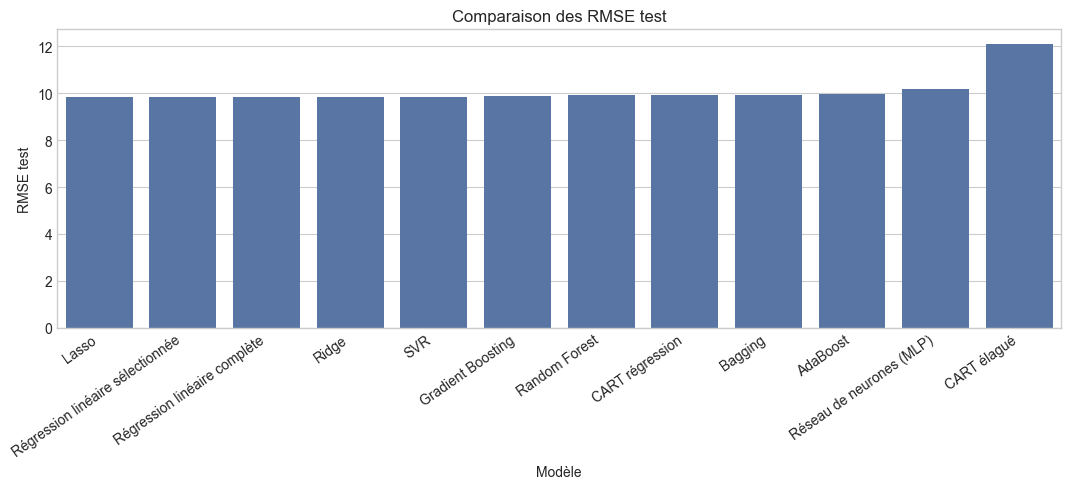

In [39]:
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_df.reset_index(drop=True), x='Modèle', y='RMSE test')
plt.title('Comparaison des RMSE test')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### Réponse à la question de comparaison sur l'échantillon test

Cette table permet de répondre directement aux questions posées :
- **quels sont les modèles les plus performants ?**
- **quel niveau de précision obtient-on ?**
- **que retenir si l'on ajoute une contrainte d'interprétabilité ?**

Si les modèles linéaires complets, sélectionnés ou pénalisés restent parmi les meilleurs, cela signifie que la relation entre `Cholesterol_LDL` et les autres variables est déjà largement captée par une structure simple, dominée par `Cholesterol_Total`.

Dans ce cas, les modèles non linéaires n'apportent aucune amélioration.

Avec une contrainte d'**interprétabilité**, on retiendra en priorité :
- la **régression linéaire sélectionnée** ;
- le **lasso** ;
- éventuellement l'**arbre élagué** si l'on souhaite une lecture par seuils(mais résultats pas terrible par rapport aux autres méthodes).



## 11. Interprétation et retour sur l'analyse des données

Même sans refaire l'analyse exploratoire complète ici, on peut revenir à la cohérence entre modélisation et structure des données.

Dans les résultats obtenus, on s'attend à retrouver très haut :
- `Cholesterol_Total` ;
- puis `Age`, `BMI`, `Systolic_BP`, `Cholesterol_HDL` ou quelques variables physiologiques proches.

Cela doit être vérifié à travers :
- les coefficients des modèles linéaires ;
- les variables sélectionnées par le lasso ;
- les importances des arbres, de la forêt ou du gradient boosting.

Quand plusieurs modèles très différents convergent vers les mêmes variables dominantes, cela renforcel'interprétation.
On a vu plus haut que c'était bien le cas.

## 12. Conclusion

Cette étude complémentaire sur `Cholesterol_LDL` montre qu'il ne suffit pas d'appliquer des modèles de plus en plus complexes pour gagner en précision. Sur cette cible, la structure du problème semble déjà largement expliquée par quelques variables très informatives, en particulier `Cholesterol_Total`.

Les principaux enseignements sont les suivants (dans ce cas précis) :
- les **modèles linéaires** constituent ici une référence très forte ;
- l'**arbre de régression** est utile pour l'interprétation par seuils, mais reste plus instable ;
- le **bagging**, la **forêt aléatoire** et le **boosting** sont intéressants à comparer, mais n'apportent pas nécessairement un gain significatif quand la relation est déjà presque linéaire ;
- le **SVR** et le **MLP** sont plus couteux pour des résultats qui ne sont pas meilleurs.

Si l'objectif principal est la **performance prédictive brute**, on retient les modèles aux plus faibles RMSE test. Si l'on ajoute une contrainte d'**interprétabilité**, les modèles linéaires sélectionnés ou pénalisés deviennent particulièrement attractifs, car ils restent très lisibles pour une perte éventuelle de précision souvent faible.

Dans notre cas ici, les plus performants sont les modèles linéaires donc on les conserve.

